# Topluluk Analizi ve Ağ Dayanıklılığı

Bu notebook'ta ilk notebookta oluşturulan CTU-13 IP ağı üzerinde topluluk analizi ve ağ dayanıklılığı analizi yapılmıştır.

Bu notebook kapsamında:

- İşlenmiş kenar listesi okunmuştur.
- Graph yapısı yeniden oluşturulmuştur.
- Louvain yöntemi ile community detection uygulanmıştır.
- Topluluklar görselleştirilmiştir.
- Stealth-like node'ların hangi topluluklarda yer aldığı incelenmiştir.
- En merkezi düğümlerin ağdan çıkarılmasıyla ağ dayanıklılığı analiz edilmiştir.
- Rastgele düğüm çıkarma ile hedefli düğüm çıkarma etkileri karşılaştırılmıştır.

In [1]:
import pandas as pd
import numpy as np

import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import community as community_louvain

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
BASE_DIR = Path("..")

PROCESSED_DATA_DIR = BASE_DIR / "data" / "processed"
OUTPUT_DIR = BASE_DIR / "outputs"

FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

edge_data_path = PROCESSED_DATA_DIR / "edge_list_general.csv"
centrality_path = PROCESSED_DATA_DIR / "centrality_results.csv"
stealth_path = PROCESSED_DATA_DIR / "stealth_like_nodes.csv"

In [3]:
edge_df = pd.read_csv(edge_data_path)
centrality_df = pd.read_csv(centrality_path)
stealth_nodes_df = pd.read_csv(stealth_path)

print("Edge list boyutu:", edge_df.shape)
print("Centrality sonuçları:", centrality_df.shape)
print("Stealth-like node sonuçları:", stealth_nodes_df.shape)

edge_df.head()

Edge list boyutu: (258027, 7)
Centrality sonuçları: (197824, 5)
Stealth-like node sonuçları: (151256, 10)


,src_ip,dst_ip,connection_count,total_packets,total_bytes,avg_duration,botnet_ratio
0,0.0.0.0,255.255.255.255,5,1639,543994,3404.900977,0.0
1,00:0b:ac:c4:e7:40,00:22:15:23:57:9e,1,2,120,0.014263,0.0
2,00:0b:ac:c5:cf:00,00:22:15:23:57:9e,1,2,120,0.008781,0.0
3,00:0c:29:97:a3:eb,ff:ff:ff:ff:ff:ff,4,4,240,0.000000,0.0
4,00:15:17:2c:e5:2d,ff:ff:ff:ff:ff:ff,5,2534,235697,3417.890674,0.0


In [5]:
# Broadcast ve MAC benzeri kayıtları temizleme

invalid_nodes = [
    "ff:ff:ff:ff:ff:ff",
    "255.255.255.255",
    "0.0.0.0"
]

edge_df = edge_df[
    ~edge_df["src_ip"].isin(invalid_nodes)
]

edge_df = edge_df[
    ~edge_df["dst_ip"].isin(invalid_nodes)
]

# MAC benzeri kayıtları temizleme
edge_df = edge_df[
    ~edge_df["src_ip"].str.contains(":", regex=False)
]

edge_df = edge_df[
    ~edge_df["dst_ip"].str.contains(":", regex=False)
]

print("Temizleme sonrası edge list boyutu:", edge_df.shape)

Temizleme sonrası edge list boyutu: (258006, 7)


In [6]:
#graph'ı yeniden oluşturma
G = nx.Graph()

for _, row in edge_df.iterrows():
    G.add_edge(
        row["src_ip"],
        row["dst_ip"],
        weight=row["connection_count"],
        total_packets=row["total_packets"],
        total_bytes=row["total_bytes"],
        avg_duration=row["avg_duration"],
        botnet_ratio=row["botnet_ratio"]
    )

print("Düğüm sayısı:", G.number_of_nodes())
print("Kenar sayısı:", G.number_of_edges())
print("Yoğunluk:", nx.density(G))

Düğüm sayısı: 197804
Kenar sayısı: 235101
Yoğunluk: 1.2017566342339843e-05


## Graph Yapısının Yeniden Oluşturulması

Bu notebookta topluluk analizi ve dayanıklılık analizi yapılacağı için ağ yönsüz graph olarak yeniden oluşturulmuştur.

Yönsüz graph kullanımı, IP adresleri arasındaki bağlantıların karşılıklı ilişki olarak değerlendirilmesini sağlar. Böylece Louvain community detection gibi topluluk bulma algoritmaları daha uygun şekilde uygulanabilir.

In [7]:
# Louvain Community Detection - hangi node hangi community'e ait?
partition = community_louvain.best_partition(G, weight="weight", random_state=42)

community_df = pd.DataFrame({
    "node": list(partition.keys()),
    "community": list(partition.values())
})

community_df.head()

,node,community
0,1.112.121.154,0
1,147.32.84.229,0
2,1.112.182.132,1
3,147.32.86.116,1
4,1.112.197.149,0


In [8]:
# topluluk sayısı ve büyüklükleri
community_summary = (
    community_df["community"]
    .value_counts()
    .reset_index()
)

community_summary.columns = ["community", "node_count"]

community_summary.head(10)

,community,node_count
0,0,130844
1,5,19620
2,1,15809
3,10,7363
4,4,4573
5,12,3921
6,20,3534
7,16,2783
8,2,2613
9,7,1598


In [9]:
print("Toplam topluluk sayısı:", community_df["community"].nunique())
print("En büyük topluluktaki node sayısı:", community_summary["node_count"].max())

Toplam topluluk sayısı: 26
En büyük topluluktaki node sayısı: 130844


In [10]:
# modularity skoru
modularity_score = community_louvain.modularity(partition, G, weight="weight")

print("Modularity skoru:", modularity_score)

Modularity skoru: 0.5438961635551673


## Topluluk Büyüklükleri

Louvain yöntemi kullanılarak ağ içerisindeki doğal topluluklar belirlenmiştir. Topluluklar, kendi içinde daha yoğun bağlantıya sahip olan düğüm gruplarını ifade etmektedir.

Modularity skoru, bulunan topluluk yapısının ne kadar anlamlı olduğunu gösterir. Hesaplanan modularity değeri, ağın belirgin topluluklara ayrıldığını göstermektedir.

Bu analiz, botnet veya stealth-like davranış gösteren IP adreslerinin belirli topluluklarda yoğunlaşıp yoğunlaşmadığını anlamak için önemlidir.

Louvain community detection algoritması sonucunda ağın birden fazla doğal topluluğa ayrıldığı görülmüştür.

Sonuçlara göre bir topluluğun oldukça büyük olduğu dikkat çekmektedir. Bu durum ağ içerisindeki çok sayıda IP adresinin yoğun şekilde birbirine bağlı olduğunu göstermektedir. Büyük topluluk, ağın ana iletişim yapısını temsil ediyor olabilir.

Daha küçük topluluklar ise:
- belirli subnet yapıları,
- sınırlı iletişim grupları,
- özel trafik örüntüleri,
- veya botnet davranışı gösteren kümeler

olabilir.

Topluluk boyutlarının dengesiz dağılım göstermesi, ağın homojen değil; belirli merkezler etrafında kümelenen organize bir yapıya sahip olduğunu göstermektedir.

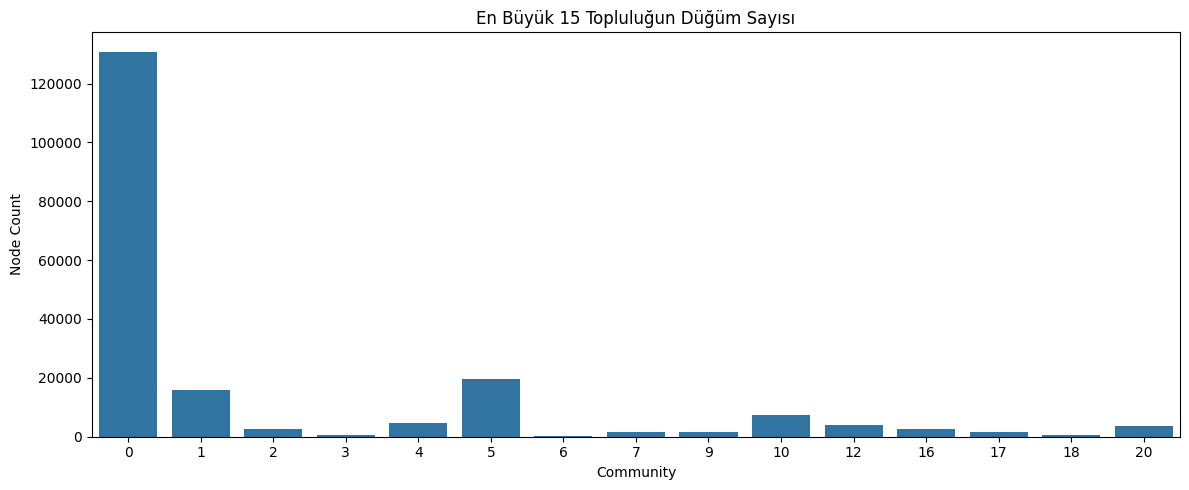

In [12]:
# topluluk büyüklükleri grafiği
plt.figure(figsize=(12, 5))

sns.barplot(
    data=community_summary.head(15),
    x="community",
    y="node_count"
)

plt.title("En Büyük 15 Topluluğun Düğüm Sayısı")
plt.xlabel("Community")
plt.ylabel("Node Count")
plt.tight_layout()
plt.show()


Grafik incelendiğinde ağ içerisindeki toplulukların boyutlarının oldukça dengesiz dağıldığı görülmektedir.

Özellikle community 0’ın diğer topluluklara göre çok daha fazla düğüm içerdiği dikkat çekmektedir. Bu durum ağ içerisindeki büyük bir ana iletişim yapısına işaret etmektedir.

Daha küçük topluluklar ise:
- belirli subnet gruplarını,
- sınırlı iletişim kümelerini,
- özel trafik örüntülerini,
- veya belirli görevler üstlenen IP gruplarını

temsil ediyor olabilir.

Topluluk boyutlarının heterojen olması, ağın rastgele değil; belirli merkezler etrafında organize olan kümelerden oluştuğunu göstermektedir.

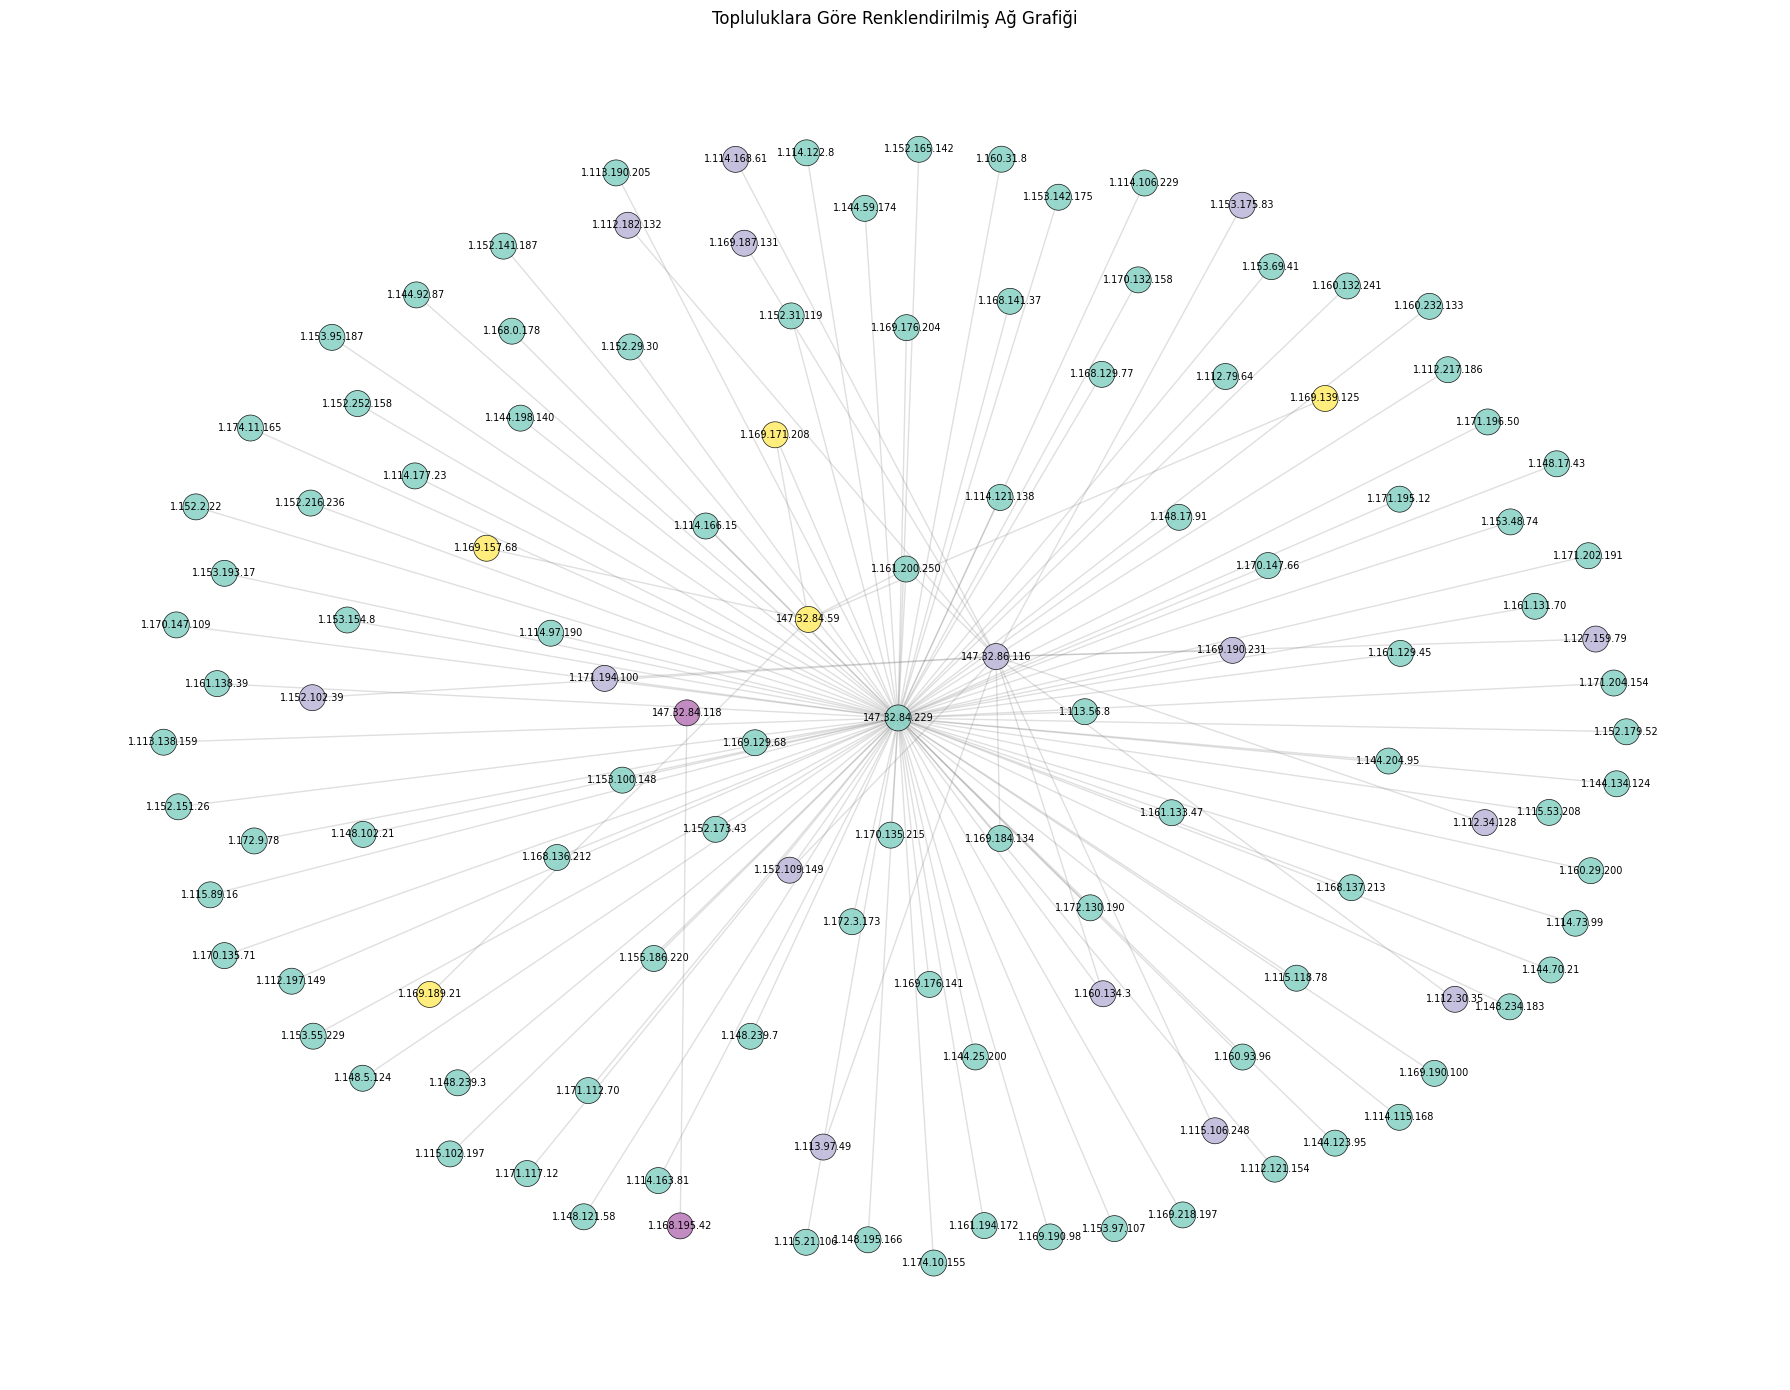

In [13]:
# topluluklara göre ağ görselleştirme
# En büyük 5 topluluğu seçelim
top_communities = community_summary.head(5)["community"].tolist()

selected_nodes = community_df[
    community_df["community"].isin(top_communities)
]["node"].tolist()

# Görselleştirme okunabilir olsun diye en fazla 120 node seçiyoruz
selected_nodes = selected_nodes[:120]

community_G = G.subgraph(selected_nodes).copy()

node_communities = [
    partition[node]
    for node in community_G.nodes()
]

plt.figure(figsize=(18, 14))

pos = nx.spring_layout(
    community_G,
    k=1.2,
    iterations=100,
    seed=42
)

nx.draw_networkx_nodes(
    community_G,
    pos,
    node_color=node_communities,
    cmap=plt.cm.Set3,
    node_size=350,
    edgecolors="black",
    linewidths=0.5,
    alpha=0.9
)

nx.draw_networkx_edges(
    community_G,
    pos,
    edge_color="gray",
    alpha=0.25
)

nx.draw_networkx_labels(
    community_G,
    pos,
    font_size=7
)

plt.title("Topluluklara Göre Renklendirilmiş Ağ Grafiği")
plt.axis("off")
plt.tight_layout()
plt.show()

Grafikte her renk farklı bir topluluğu temsil etmektedir. Aynı renkteki düğümler kendi aralarında daha yoğun bağlantı kuran IP adreslerinden oluşmaktadır.

Ağ yapısı incelendiğinde bazı merkezi düğümlerin farklı topluluklarla bağlantı kurduğu görülmektedir. Bu düğümler topluluklar arası geçiş noktası veya köprü düğüm olarak değerlendirilebilir.

Bazı toplulukların yıldız benzeri yapı oluşturması, belirli merkezi IP adresleri etrafında yoğun iletişim gerçekleştiğini göstermektedir. Bu durum:
- istemci-sunucu yapısı,
- subnet merkezleri,
- veya botnet koordinasyon noktaları

ile ilişkili olabilir.

Ayrıca toplulukların tamamen izole olmadığı, bazı düğümler aracılığıyla birbirleriyle bağlantı kurduğu gözlemlenmektedir. Bu durum ağ içerisinde bilgi veya trafik akışının belirli geçiş noktaları üzerinden gerçekleştiğini göstermektedir.

In [14]:
# steath-like node'ların toplulukları
stealth_nodes = stealth_nodes_df[
    stealth_nodes_df["is_stealth_like"] == 1
]["src_ip"].tolist()

stealth_community_df = community_df[
    community_df["node"].isin(stealth_nodes)
].copy()

stealth_community_summary = (
    stealth_community_df["community"]
    .value_counts()
    .reset_index()
)

stealth_community_summary.columns = ["community", "stealth_node_count"]

stealth_community_summary.head(10)

,community,stealth_node_count
0,0,4655
1,20,201
2,1,156
3,4,79
4,5,47
5,10,44
6,2,25
7,7,21
8,12,20
9,16,14


In [15]:
print("Stealth-like node sayısı:", len(stealth_nodes))
print("Topluluk analizine dahil olan stealth-like node sayısı:", stealth_community_df.shape[0])
print("Stealth-like node'ların bulunduğu topluluk sayısı:", stealth_community_df["community"].nunique())

Stealth-like node sayısı: 5303
Topluluk analizine dahil olan stealth-like node sayısı: 5301
Stealth-like node'ların bulunduğu topluluk sayısı: 18


## Stealth-like Node ve Topluluk İlişkisi

Analiz sonuçlarına göre stealth-like davranış gösteren düğümlerin büyük kısmı community 0 içerisinde yer almaktadır. Bu durum şüpheli davranışların ağın ana iletişim yapısı içerisinde yoğunlaştığını göstermektedir.

Stealth-like node'ların tamamen ayrı ve izole bir topluluk oluşturmak yerine normal ağ trafiği içerisine dağıldığı görülmektedir. Bu yapı stealth-benzeri davranışların temel karakteristiği ile uyumludur. Çünkü stealth trafik genellikle dikkat çekmeden normal trafik içerisinde gizlenmeye çalışır.

Ayrıca stealth-like node'ların toplam 18 farklı topluluk içerisinde bulunması, bu davranışın ağın yalnızca belirli bir bölgesine ait olmadığını; ağın farklı kısımlarına yayılmış dağıtık bir yapı sergilediğini göstermektedir.

Bu sonuçlar ağ içerisindeki şüpheli davranışların tek merkezli değil, çok bölgeli ve dağıtık bir örüntü oluşturabileceğini göstermesi açısından önemlidir.

In [16]:
# köprü node analizi
bridge_nodes_df = centrality_df.sort_values(
    "betweenness",
    ascending=False
).head(10)

bridge_nodes_df

,node,degree_centrality,betweenness,closeness,pagerank
0,147.32.84.229,0.783872,0.248204,0.282185,0.229347
1,147.32.84.59,0.133079,0.072636,0.426575,0.019296
2,147.32.86.116,0.100908,0.029673,0.289729,0.023936
3,147.32.84.118,0.038307,0.019934,0.348899,0.007309
46,147.32.80.9,0.001481,0.014240,0.519170,0.020663
103,147.32.80.13,0.000536,0.006303,0.368159,0.002096
5,147.32.84.94,0.007658,0.006153,0.334109,0.000874
4,147.32.86.165,0.016131,0.005154,0.259197,0.005018
9,147.32.84.68,0.006081,0.003183,0.336378,0.000392
22,147.32.86.114,0.003569,0.002674,0.258810,0.000994


In [17]:
bridge_community_df = bridge_nodes_df.merge(
    community_df,
    on="node",
    how="left"
)

bridge_community_df

,node,degree_centrality,betweenness,closeness,pagerank,community
0,147.32.84.229,0.783872,0.248204,0.282185,0.229347,0
1,147.32.84.59,0.133079,0.072636,0.426575,0.019296,5
2,147.32.86.116,0.100908,0.029673,0.289729,0.023936,1
3,147.32.84.118,0.038307,0.019934,0.348899,0.007309,4
4,147.32.80.9,0.001481,0.014240,0.519170,0.020663,16
5,147.32.80.13,0.000536,0.006303,0.368159,0.002096,5
6,147.32.84.94,0.007658,0.006153,0.334109,0.000874,12
7,147.32.86.165,0.016131,0.005154,0.259197,0.005018,2
8,147.32.84.68,0.006081,0.003183,0.336378,0.000392,12
9,147.32.86.114,0.003569,0.002674,0.258810,0.000994,10


Merkezilik sonuçları incelendiğinde bazı IP adreslerinin ağ içerisinde oldukça baskın rol üstlendiği görülmektedir.

Özellikle:
- 147.32.84.229
- 147.32.84.59
- 147.32.86.116

gibi düğümler hem yüksek degree centrality hem de yüksek betweenness centrality değerlerine sahiptir.

Bu durum ilgili IP adreslerinin:
- çok sayıda bağlantıya sahip olduğunu,
- farklı ağ bölgeleri arasında geçiş noktası görevi gördüğünü,
- ve ağ içerisindeki iletişim akışında kritik rol oynadığını göstermektedir.

Ayrıca bazı düğümlerin yüksek PageRank değerine sahip olması, yalnızca çok bağlantılı olmadıklarını; aynı zamanda önemli düğümlerle iletişim kurduklarını göstermektedir.

In [18]:
# ağ dayanıklılığı için fonksiyon
def calculate_resilience_metrics(graph):
    """
    Verilen graph için dayanıklılık metriklerini hesaplar.
    """
    node_count = graph.number_of_nodes()
    edge_count = graph.number_of_edges()
    density = nx.density(graph) if node_count > 1 else 0
    
    components = list(nx.connected_components(graph))
    component_count = len(components)
    
    largest_component_size = max([len(c) for c in components]) if components else 0
    
    return {
        "node_count": node_count,
        "edge_count": edge_count,
        "density": density,
        "component_count": component_count,
        "largest_component_size": largest_component_size
    }

In [19]:
# başlangıç metrikleri
baseline_metrics = calculate_resilience_metrics(G)

baseline_metrics

{'node_count': 197804,
 'edge_count': 235101,
 'density': 1.2017566342339843e-05,
 'component_count': 7,
 'largest_component_size': 197793}

Başlangıç ağ yapısı incelendiğinde ağın oldukça büyük ölçekli ve seyrek (sparse) yapıda olduğu görülmektedir.

Ağ:
- yaklaşık 198 bin düğüm,
- 235 bin kenar,
- ve 7 bağlı component

içermektedir.

En büyük component içerisinde düğümlerin büyük çoğunluğunun yer alması, ağın önemli ölçüde bağlantılı bir yapı sergilediğini göstermektedir.

In [20]:
# en yüksek dereceli nodu'u çıkarma
degree_dict = dict(G.degree())

highest_degree_node = max(degree_dict, key=degree_dict.get)

G_remove_degree = G.copy()
G_remove_degree.remove_node(highest_degree_node)

degree_removed_metrics = calculate_resilience_metrics(G_remove_degree)

print("Çıkarılan highest degree node:", highest_degree_node)
degree_removed_metrics

Çıkarılan highest degree node: 147.32.84.229


{'node_count': 197803,
 'edge_count': 93588,
 'density': 4.783949752765527e-06,
 'component_count': 125524,
 'largest_component_size': 72275}

En yüksek degree değerine sahip düğüm ağdan çıkarıldığında ağ yapısında çok ciddi değişimler meydana gelmiştir.

Özellikle:
- component sayısının 7’den 125524’e yükselmesi,
- en büyük component boyutunun ciddi şekilde küçülmesi,
- kenar sayısının büyük ölçüde azalması

ilgili düğümün ağ bağlantılarının merkezinde yer aldığını göstermektedir.

Bu sonuç, ağın belirli merkezi düğümlere yüksek derecede bağımlı olduğunu ve bu düğümlerin ağ bütünlüğü açısından kritik rol oynadığını ortaya koymaktadır.

In [21]:
# en yüksek betweenness değerine sahip node'u çıkarma
highest_betweenness_node = bridge_nodes_df.iloc[0]["node"]

G_remove_betweenness = G.copy()
G_remove_betweenness.remove_node(highest_betweenness_node)

betweenness_removed_metrics = calculate_resilience_metrics(G_remove_betweenness)

print("Çıkarılan highest betweenness node:", highest_betweenness_node)
betweenness_removed_metrics

Çıkarılan highest betweenness node: 147.32.84.229


{'node_count': 197803,
 'edge_count': 93588,
 'density': 4.783949752765527e-06,
 'component_count': 125524,
 'largest_component_size': 72275}

En yüksek betweenness centrality değerine sahip düğüm çıkarıldığında ağ yapısının büyük ölçüde parçalandığı görülmektedir.

Bu durum ilgili düğümün:
- topluluklar arası geçiş noktası,
- köprü düğüm,
- ve kritik trafik bağlantı noktası

olarak davrandığını göstermektedir.

Betweenness değeri yüksek düğümlerin kaldırılması, ağ içerisindeki bilgi akışının ciddi şekilde bozulmasına neden olabilmektedir.

In [ ]:
# rastgele node çıkarma
np.random.seed(42)

random_node = np.random.choice(list(G.nodes()))

G_remove_random = G.copy()
G_remove_random.remove_node(random_node)

random_removed_metrics = calculate_resilience_metrics(G_remove_random)

print("Çıkarılan rastgele node:", random_node)
random_removed_metrics

Rastgele seçilen bir düğüm ağdan çıkarıldığında ağ yapısında neredeyse hiçbir önemli değişim gözlemlenmemiştir.

Component sayısı, yoğunluk ve en büyük component boyutu büyük ölçüde korunmuştur.

Bu durum ağın rastgele düğüm kayıplarına karşı dayanıklı olduğunu; ancak merkezi düğümlere yönelik hedefli müdahalelere karşı hassas olduğunu göstermektedir.

In [23]:
# dayanıklılık sonuçlarını karşılaştırma
resilience_comparison_df = pd.DataFrame([
    {"scenario": "Baseline", **baseline_metrics},
    {"scenario": "Remove Highest Degree Node", **degree_removed_metrics},
    {"scenario": "Remove Highest Betweenness Node", **betweenness_removed_metrics},
    {"scenario": "Remove Random Node", **random_removed_metrics}
])

resilience_comparison_df

,scenario,node_count,edge_count,density,component_count,largest_component_size
0,Baseline,197804,235101,0.000012,7,197793
1,Remove Highest Degree Node,197803,93588,0.000005,125524,72275
2,Remove Highest Betweenness Node,197803,93588,0.000005,125524,72275
3,Remove Random Node,197803,235100,0.000012,7,197792


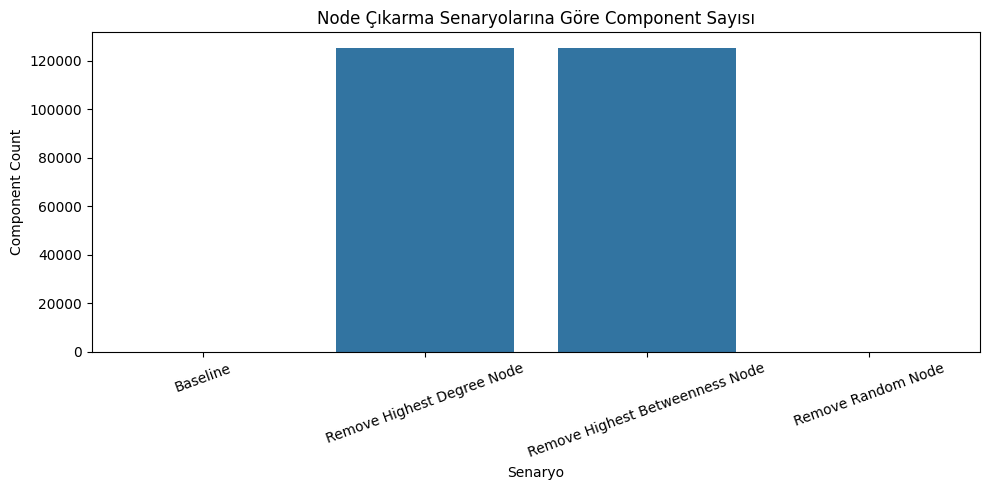

In [24]:
# component sayısı karşılaştırma
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resilience_comparison_df,
    x="scenario",
    y="component_count"
)

plt.title("Node Çıkarma Senaryolarına Göre Component Sayısı")
plt.xlabel("Senaryo")
plt.ylabel("Component Count")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Grafik incelendiğinde en yüksek degree ve betweenness değerine sahip düğümlerin çıkarılması sonucunda ağın çok sayıda parçaya ayrıldığı görülmektedir.

Buna karşılık rastgele düğüm çıkarma senaryosunda component sayısında önemli bir değişim oluşmamıştır.

Bu sonuç ağın:
- merkezi düğümlere bağımlı olduğunu,
- ancak rastgele hatalara karşı dayanıklı bir yapı sergilediğini

göstermektedir.

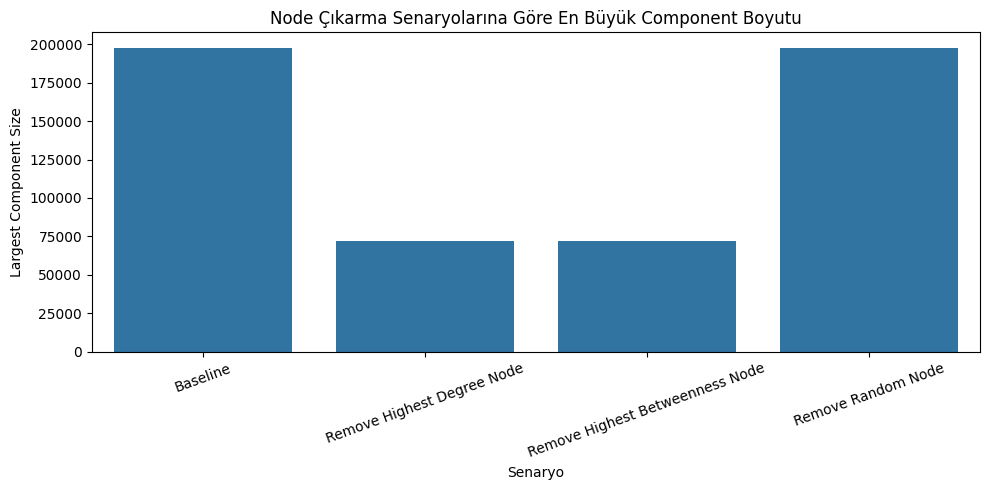

In [25]:
# largest component size karşılaştırma
plt.figure(figsize=(10, 5))

sns.barplot(
    data=resilience_comparison_df,
    x="scenario",
    y="largest_component_size"
)

plt.title("Node Çıkarma Senaryolarına Göre En Büyük Component Boyutu")
plt.xlabel("Senaryo")
plt.ylabel("Largest Component Size")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Merkezi düğümlerin çıkarılması sonucunda en büyük component boyutunda ciddi düşüş meydana geldiği görülmektedir.

Bu durum ağın büyük bölümünün belirli merkezi IP adresleri üzerinden birbirine bağlı olduğunu göstermektedir.

Özellikle highest degree ve highest betweenness node çıkarıldığında ağın ana iletişim yapısının önemli ölçüde bozulduğu gözlemlenmiştir.

Rastgele düğüm çıkarıldığında ise en büyük component boyutunun neredeyse değişmemesi, ağın rastgele node kayıplarına karşı dayanıklı olduğunu göstermektedir.

In [28]:
# sonuçları kaydet
community_path = PROCESSED_DATA_DIR / "community_results.csv"
community_summary_path = PROCESSED_DATA_DIR / "community_summary.csv"
resilience_path = PROCESSED_DATA_DIR / "resilience_comparison.csv"
stealth_community_path = PROCESSED_DATA_DIR / "stealth_community_results.csv"

community_df.to_csv(community_path, index=False)
community_summary.to_csv(community_summary_path, index=False)
resilience_comparison_df.to_csv(resilience_path, index=False)
stealth_community_df.to_csv(stealth_community_path, index=False)

print("Community results saved:", community_path)
print("Community summary saved:", community_summary_path)
print("Resilience comparison saved:", resilience_path)
print("Stealth community results saved:", stealth_community_path)

Community results saved: ..\data\processed\community_results.csv
Community summary saved: ..\data\processed\community_summary.csv
Resilience comparison saved: ..\data\processed\resilience_comparison.csv
Stealth community results saved: ..\data\processed\stealth_community_results.csv


# Sonuç ve Değerlendirme

Bu notebook kapsamında CTU-13 veri setinden oluşturulan IP ağı üzerinde topluluk analizi ve ağ dayanıklılığı analizi gerçekleştirilmiştir.

İlk aşamada Louvain community detection algoritması kullanılarak ağ içerisindeki doğal topluluk yapıları belirlenmiştir. Elde edilen yaklaşık 0.54 modularity skoru, ağın belirgin ve anlamlı topluluklara ayrıldığını göstermektedir. Topluluk analizleri sonucunda bazı IP gruplarının kendi içlerinde yoğun iletişim kurduğu ve ağın tamamen rastgele bir yapı sergilemediği gözlemlenmiştir.

Topluluk görselleştirmeleri incelendiğinde bazı merkezi düğümlerin farklı topluluklar arasında bağlantı kurduğu görülmüştür. Bu düğümler ağ içerisinde köprü (bridge node) görevi gören kritik iletişim noktaları olarak değerlendirilmiştir.

Stealth-like node analizinde şüpheli davranış gösteren düğümlerin büyük bölümünün ana topluluk içerisinde yer aldığı görülmüştür. Ayrıca stealth-like node’ların farklı topluluklara dağıldığı ve ağın yalnızca tek bir bölgesinde yoğunlaşmadığı gözlemlenmiştir. Bu durum stealth-benzeri davranışların normal ağ trafiği içerisine yayılmış şekilde gerçekleşebileceğini göstermektedir.

Ağ dayanıklılığı analizinde ise:
- en yüksek degree değerine sahip düğüm,
- en yüksek betweenness değerine sahip düğüm,
- ve rastgele seçilen bir düğüm

ağdan çıkarılarak ağ yapısındaki değişimler karşılaştırılmıştır.

Sonuçlar, merkezi düğümlerin çıkarılması durumunda ağın ciddi şekilde parçalandığını göstermiştir. Özellikle component sayısındaki büyük artış ve en büyük component boyutundaki düşüş, ağın belirli kritik düğümlere yüksek derecede bağımlı olduğunu ortaya koymaktadır.

Buna karşılık rastgele düğüm çıkarma senaryosunda ağ yapısında önemli bir bozulma oluşmamıştır. Bu durum ağın rastgele node kayıplarına karşı dayanıklı, ancak merkezi düğümlere yönelik hedefli müdahalelere karşı hassas olduğunu göstermektedir.

Genel olarak bu çalışma:
- temporal ağ analizi,
- merkezilik analizi,
- topluluk analizi,
- stealth-like davranış tespiti,
- ve ağ dayanıklılığı

yaklaşımlarını birlikte kullanarak ağ yapısının davranışsal özelliklerini incelemiştir.

Elde edilen sonuçlar, sosyal ağ analizi yöntemlerinin siber güvenlik ve botnet davranışı incelemelerinde etkili şekilde kullanılabileceğini göstermektedir.